# BPT diagram
To separate these different classes of galaxies on a BPT diagram plotting **[O III]$\lambda5007$/H$\beta$** versus **[N II]$\lambda6583$/H$\alpha$**, you can use a combination of theoretical and empirical demarcation lines. 

For the formulas below, let:
*   $y = \log([\text{O III}] / \text{H}\beta)$
*   $x = \log([\text{N II}] / \text{H}\alpha)$

**1. Pure Star-Forming Galaxies**
Galaxies powered purely by star formation fall below the empirical boundary defined by Kauffmann et al. (2003).
**Formula:** $y < \frac{0.61}{x - 0.05} + 1.30$

**2. Composite (Transition) Galaxies**
These objects have spectra indicating a blend of star formation and AGN activity. They fall between the Kauffmann (2003) empirical line and the theoretical maximum starburst line defined by Kewley et al. (2001).
**Formula:** $\frac{0.61}{x - 0.05} + 1.30 < y < \frac{0.61}{x - 0.47} + 1.19$

**3. Active Galactic Nuclei (AGN)**
Galaxies that are entirely dominated by an AGN (which includes both Seyferts and LINERs) fall above the Kewley (2001) theoretical maximum starburst line. These objects cannot be explained by any combination of star formation parameters.
**Formula:** $y > \frac{0.61}{x - 0.47} + 1.19$

**4. Separating Seyferts from LINERs**
Within the AGN regime (above the Kewley 2001 line), objects are further split based on their ionization state. While the [S II] and [O I] diagrams are often preferred for this separation, an empirical dividing line specific to the [N II]/H$\alpha$ diagram was defined by Schawinski et al. (2007).
**Demarcation Line Formula:** $y = 1.05x + 0.45$
*   **Seyfert galaxies** have higher ionization ratios and fall **above** this line ($y > 1.05x + 0.45$).
*   **LINER galaxies** have lower ionization ratios and fall **below** this line ($y < 1.05x + 0.45$).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sdss.metadata import MetaData
from anomaly.utils import specobjid_to_idx

meta = MetaData()
pd.set_option("display.max_columns", None)

# Custom functions

## BPT boundaries

In [3]:
def bpt_boundary_lines():
    # Kauffmann et al. (2003) - Empirical Star-Forming line
    x_kauff = np.linspace(-2.0, 0.0, 1000)
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    # Kewley et al. (2001) - Theoretical Maximum Starburst line
    x_kewley = np.linspace(-2.0, 0.4, 1000)
    y_kewley = 0.61 / (x_kewley - 0.47) + 1.19

    # Schawinski et al. (2007) - Seyfert / LINER division
    x_schaw = np.linspace(-0.18, 1.5, 1000)
    y_schaw = 1.05 * x_schaw + 0.45

    return (x_kauff, y_kauff), (x_kewley, y_kewley), (x_schaw, y_schaw)

## BPT figure

In [4]:
def plot_bpt(
    fig, ax, n2_ha, o3_hb, labels, xytext=(0, 0), x_lim=[-1.5, 1.0], y_lim=[-1.5, 1.5]
):
    """
    Plots a standard [N II] BPT diagram.

    Parameters:
    n2_ha : array-like
        log10([N II] 6584 / H_alpha)
    o3_hb : array-like
        log10([O III] 5007 / H_beta)
    """
    # Demarcation Lines
    (x_kauff, y_kauff), (x_kewley, y_kewley), (x_schaw, y_schaw) = bpt_boundary_lines()

    ax.plot(x_kauff, y_kauff, "k--", lw=2, label="Kauffmann+03 (SF/Composite)")

    ax.plot(x_kewley, y_kewley, "k-", lw=2, label="Kewley+01 (Composite/AGN)")

    ax.plot(x_schaw, y_schaw, "k-.", lw=2, label="Schawinski+07 (Seyfert/LINER)")

    # Data
    ax.scatter(n2_ha, o3_hb, color="red")
    # labels
    for x, y, label in zip(n2_ha, o3_hb, labels):

        if np.isnan(x) or np.isnan(y):
            continue

        ax.annotate(
            label,
            (x, y),
            # x points right and y points up from the marker
            xytext=xytext,
            # Use offset in points rather than axis coordinates
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            va="bottom",
            ha="left",
        )
    # -------------------------------------------------------------
    # 3. Formatting
    # -------------------------------------------------------------
    # Add region text labels
    ax.text(-1.0, -0.5, "Star Forming", fontsize=14, ha="center")
    ax.text(-0.15, -0.5, "Composite", fontsize=14, ha="center", rotation=-70)
    ax.text(-0.5, 1.25, "Seyfert", fontsize=14, ha="center")
    ax.text(0.5, -0.5, "LINER", fontsize=14, ha="center")

    # Set axis limits and labels
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_xlabel(r"$\log_{10}([\mathrm{N~II}] / \mathrm{H}\alpha)$", fontsize=14)
    ax.set_ylabel(r"$\log_{10}([\mathrm{O~III}] / \mathrm{H}\beta)$", fontsize=14)
    ax.tick_params(labelsize=12)

    ax.legend(loc="lower left", fontsize=8, frameon=False)

    return fig, ax

## Overview data

In [5]:
def get_overview_ratios_df(overview_dict, meta_with_ratios_df, cols_ratios):

    ratios_overview_dict = {
        "specobjid": [],
        "name": [],
        "class": [],
        "balmer_decrement": [],
        "nii_to_halpha": [],
        "oiii_to_hbeta": [],
        "oiii_to_oii": [],
        "o3n2_index": [],
        "sii_to_halpha": [],
        "sii_density_ratio": [],
    }

    for title, specid in overview_dict.items():

        ratios_overview_dict["name"].append(title)
        ratios_overview_dict["specobjid"].append(specid)

        try:
            class_ = final_meta_df.loc[specid, "subClass"]
            ratios_overview_dict["class"].append(class_)

        except KeyError:
            ratios_overview_dict["class"].append(np.nan)

        for col in cols_ratios:
            try:
                ratios_overview_dict[col].append(meta_with_ratios_df.loc[specid, col])
            except KeyError:
                ratios_overview_dict[col].append(np.nan)

    ratios_overview_df = pd.DataFrame(ratios_overview_dict)

    return ratios_overview_df

# Config

## Constants

In [6]:
se_cols = ["mse", "mse_filter_250", "mse_97", "mse_filter_250_97"]
se_rank_cols = [f"rank_{col}" for col in se_cols]
# ----------------------------------------------
rse_cols = [f"{col}_rel" for col in se_cols]
rse_rank_cols = [f"rank_{col}_rel" for col in se_cols]
# ----------------------------------------------
se_family = ["mse", "mse_97", "mse_filter_250", "mse_filter_250_97"]
rse_family = [f"{col}_rel" for col in se_family]

In [7]:
cols_ratios = [
    "balmer_decrement",
    "nii_to_halpha",
    "oiii_to_hbeta",
    "oiii_to_oii",
    "o3n2_index",
    "sii_to_halpha",
    "sii_density_ratio",
]

## Directories

In [8]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
ch_4_dir = f"{thesis_dir}/chapters/04_figures"

# Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

# lines_df = pd.read_csv(
#     f"{spectra_dir}/meta_data/lines_EdgarOrtiz.csv",
#     index_col="specObjID",
# )

# meta_with_lines_df = pd.read_csv(
#     f"{spectra_dir}/final_spec_n_z_warning_drop_with_lines.csv.gz",
#     index_col="specobjid",
# )

In [10]:
# meta_with_ratios_df.head(3)
# final_meta_df.head(3)

# Scores

## SE + RSE scores

In [11]:
# bin_id = "bin_03"
# res_scores_03_df = pd.read_csv(
#     f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
#     usecols=["specobjid"] + se_cols + rse_cols,
#     index_col="specobjid",
# )

# rank = np.arange(res_scores_03_df.shape[0]) + 1
# res_03_scores_rank_df = res_scores_03_df.copy()
# # score_rank_df
# for col in res_scores_03_df.columns:

#     index_sorted = res_scores_03_df.sort_values(by=col, ascending=False).index

#     res_03_scores_rank_df.loc[index_sorted, f"rank_{col}"] = rank
#     res_03_scores_rank_df[f"rank_{col}"].astype(int)

# n_spec = res_scores_03_df.shape[0]
# n_top_1_pct = int(n_spec * 0.01)
# n_top_1_pct, n_spec

In [12]:
# res_03_scores_rank_df.head()

# Residual scores

## Super Nova check

In [13]:
specid = 1534667320067123200
final_meta_df.loc[specid]

mjd                       53053
plate                      1363
fiberid                     239
run2d                        26
ra                    166.12941
dec                   42.624543
z                       0.12611
zErr                   0.000008
zWarning                      0
class                    GALAXY
subClass          AGN BROADLINE
z_noqso                       0
zErr_noqso                    0
zWarning_noqso                0
targetType              SCIENCE
programname              legacy
instrument                 SDSS
snMedian               20.68619
ABSSB                       AGN
BROAD                 BROADLINE
ebv                    0.006916
indexArray              86408.0
Name: 1534667320067123200, dtype: object

In [14]:
# specid = 2191010072388200448
# idx_spec = specobjid_to_idx(specid, idx_id_spec)
# wavelength = wave_nm * 10.0
# flux = spectra[idx_spec]

# spectrum_data = np.column_stack((wavelength, flux))
# save_path = f'/home/elom/phd/SN_classifier/for_classification/{specid}.txt'
# np.savetxt(save_path, spectrum_data, fmt='%.6e', delimiter=' ')
# fig, ax = plt.subplots(1,1, figsize=(10, 5))
# ax.plot(wavelength, flux, color='black')

## Common anomalies

In [15]:
overview_common_dict = {
    # row 1
    "narrow_line": 734111514142730240,
    "broad_line_large_OIII": 1633733043925575680,
    # row 2
    "broad_emission_dips_OIII_half": 1192355533059811328,
    "star_forming_step_blue_slope": 1959124163192973312,
    # row 3
    "blue_bump_emission": 531492683672217600,
    "passive_star": 1780176998165932032,
    # row 4
    "spike": 1413149843194406912,
    "noise_forest": 637325355518027776,
}

res_ratios_common_df = get_overview_ratios_df(
    overview_common_dict, meta_with_ratios_df, cols_ratios
)
res_ratios_common_df

,specobjid,name,class,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,734111514142730240,narrow_line,STARBURST,3.293360,0.050160,3.990424,NaN,1.900664,0.163502,1.362553
1,1633733043925575680,broad_line_large_OIII,STARBURST,3.891876,0.204359,10.550430,11.752099,1.712876,0.217171,1.109206
2,1192355533059811328,broad_emission_dips_OIII_half,AGN BROADLINE,5.013954,0.599002,8.754367,7.460670,1.164797,0.344767,1.184883
3,1959124163192973312,star_forming_step_blue_slope,STARBURST,3.437888,0.182478,1.409797,0.595381,0.887945,0.278217,1.376201
4,531492683672217600,blue_bump_emission,STARFORMING,3.584317,0.371369,0.517071,0.429446,0.143744,0.333807,1.389607
5,1780176998165932032,passive_star,NaN,NaN,NaN,NaN,0.123804,NaN,NaN,NaN
6,1413149843194406912,spike,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,637325355518027776,noise_forest,NaN,5.763929,0.055846,0.861052,0.411711,1.188040,NaN,NaN


## BPT

[-1.29964463 -0.68960564 -0.22257193 -0.73878858 -0.43019399         nan
         nan -1.25301047]
[ 0.60101899  1.02327017  0.94222474  0.14915656 -0.28644996         nan
         nan -0.06497042]
['(1)', '(2)', '(3)', '(4)', '(5)', '(6)', '(7)', '(8)']


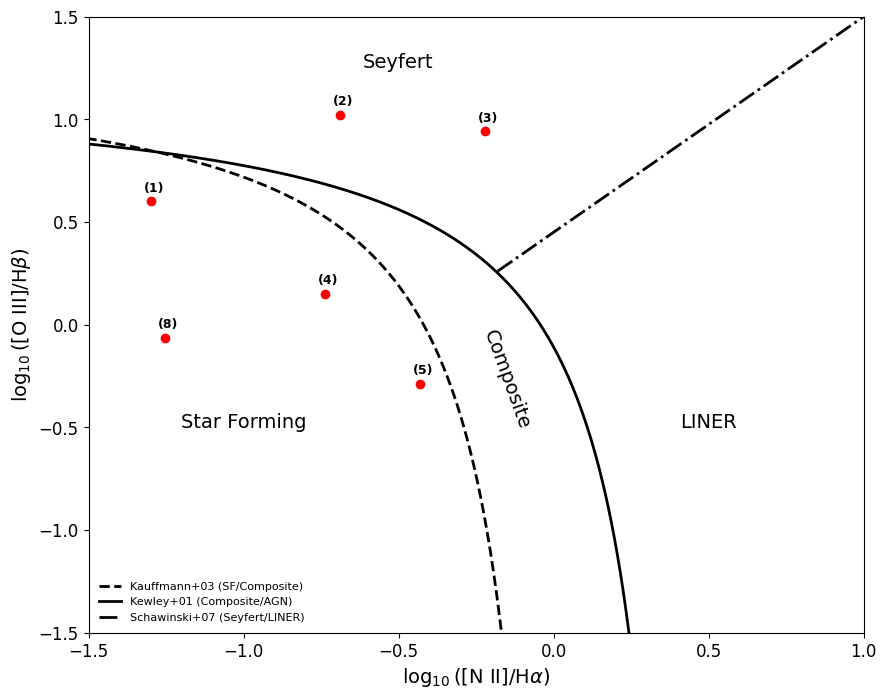

In [16]:
n2_ha = res_ratios_common_df["nii_to_halpha"].values
o3_hb = res_ratios_common_df["oiii_to_hbeta"].values
# labels = res_ratios_common_df["name"].values
labels = [f"({i})" for i in range(1, 9)]
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)
print(log_n2_ha)
print(log_o3_hb)
print(labels)

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = plot_bpt(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

## Distinct anomalies

In [17]:
overview_distinct_dict = {
    "SE": 2201231682403592192,
    "Filter SE": 2203468363479410688,
    "Trim SE": 312016418084251648,
    "Filter + Trim SE": 2191010072388200448,
    "RSE": 1534667320067123200,
    "Filter RSE": 2032375840699869184,
    "Trim RSE": 1781231151415846912,
    "Filter + Trim RSE": 2486018670363437056,
}
res_ratios_distinct_df = get_overview_ratios_df(
    overview_distinct_dict, meta_with_ratios_df, cols_ratios
)
res_ratios_distinct_df

,specobjid,name,class,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,2201231682403592192,SE,STARBURST,4.738619,0.290410,1.061164,1.354240,0.562771,0.203339,1.226524
1,2203468363479410688,Filter SE,AGN BROADLINE,4.685956,1.397339,9.826924,2.980206,0.847116,0.617020,1.245362
2,312016418084251648,Trim SE,STARFORMING,2.961808,0.218282,1.612421,0.922205,0.868461,0.345690,1.488008
3,2191010072388200448,Filter + Trim SE,NaN,0.671624,NaN,NaN,NaN,NaN,NaN,NaN
4,1534667320067123200,RSE,AGN BROADLINE,4.056508,1.114394,5.412982,2.414364,0.686398,0.807030,1.242794
5,2032375840699869184,Filter RSE,STARFORMING,3.559938,0.151456,1.483852,NaN,0.991106,0.419481,1.528695
6,1781231151415846912,Trim RSE,NaN,4.780697,0.955051,1.388111,1.538230,0.162398,0.978182,0.963864
7,2486018670363437056,Filter + Trim RSE,NaN,2.838952,1.235618,3.983498,4.972911,0.508380,0.795147,4.983828


## BPT

In [18]:
res_labels = []
for label in res_ratios_distinct_df["name"].to_list():

    _label = label.replace("Filter", "F")
    _label = _label.replace("Trim", "T")

    if " + " in label:
        _label = _label.replace(" + ", "+")

    # _label = _label.replace(' ', '\n')
    print(_label)
    res_labels.append(_label)

SE
F SE
T SE
F+T SE
RSE
F RSE
T RSE
F+T RSE


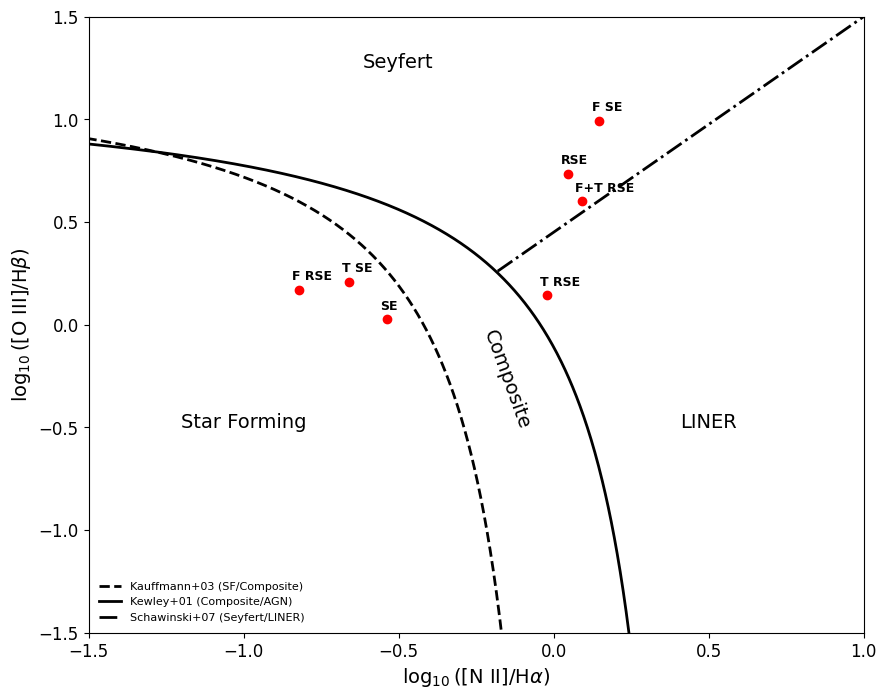

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

n2_ha = res_ratios_distinct_df["nii_to_halpha"].values
o3_hb = res_ratios_distinct_df["oiii_to_hbeta"].values
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)

labels = res_labels  # res_ratios_distinct_df["name"].values
fig, ax = plot_bpt(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

# Latent space

## Common anomalies

In [20]:
latent_overview_common_dict = {
    "emission_blue_strong_OII": 1959124163192973312,
    "emission_red_bumpy": 2006491952928811008,
    #
    "strong_emission_no_OII_OIII": 2930814289679771648,
    "broad_OIII_cut": 465054141559891968,
    #
    "broad_strong_emission_OIII": 1633733043925575680,
    "broad_strong_emission_OII_beta_cut": 1189119947666647040,
    #
    "evolved": 1444661293335209984,
    "evolved_artifact": 2217029189603715072,
    #
    "blue": 1119282266950887424,
    "red": 761223822287333376,
}

In [21]:
latent_overview_common_df = get_overview_ratios_df(
    overview_dict=latent_overview_common_dict,
    meta_with_ratios_df=meta_with_ratios_df,
    cols_ratios=cols_ratios,
)
latent_overview_common_df.to_clipboard()
latent_overview_common_df

,specobjid,name,class,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,1959124163192973312,emission_blue_strong_OII,STARBURST,3.437888,0.182478,1.409797,0.595381,0.887945,0.278217,1.376201
1,2006491952928811008,emission_red_bumpy,STARFORMING,4.197081,0.122979,2.362609,1.988466,1.283559,0.245222,1.625867
2,2930814289679771648,strong_emission_no_OII_OIII,NaN,3.047579,0.087129,816.104492,NaN,3.971585,0.127207,1.358839
3,465054141559891968,broad_OIII_cut,AGN BROADLINE,4.281604,0.614359,4.825841,4.988035,0.895151,0.371156,0.977601
4,1633733043925575680,broad_strong_emission_OIII,STARBURST,3.891876,0.204359,10.550430,11.752099,1.712876,0.217171,1.109206
5,1189119947666647040,broad_strong_emission_OII_beta_cut,AGN,3.515623,0.348532,9.911598,9.540687,1.453902,0.240694,1.226569
6,1444661293335209984,evolved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2217029189603715072,evolved_artifact,NaN,4.780570,1.127277,1.023974,NaN,-0.041742,NaN,NaN
8,1119282266950887424,blue,NaN,0.702630,0.066879,0.077679,0.467213,0.065012,NaN,NaN
9,761223822287333376,red,NaN,6.511904,1.145245,2.124747,NaN,0.268409,0.839060,1.607370


## BPT

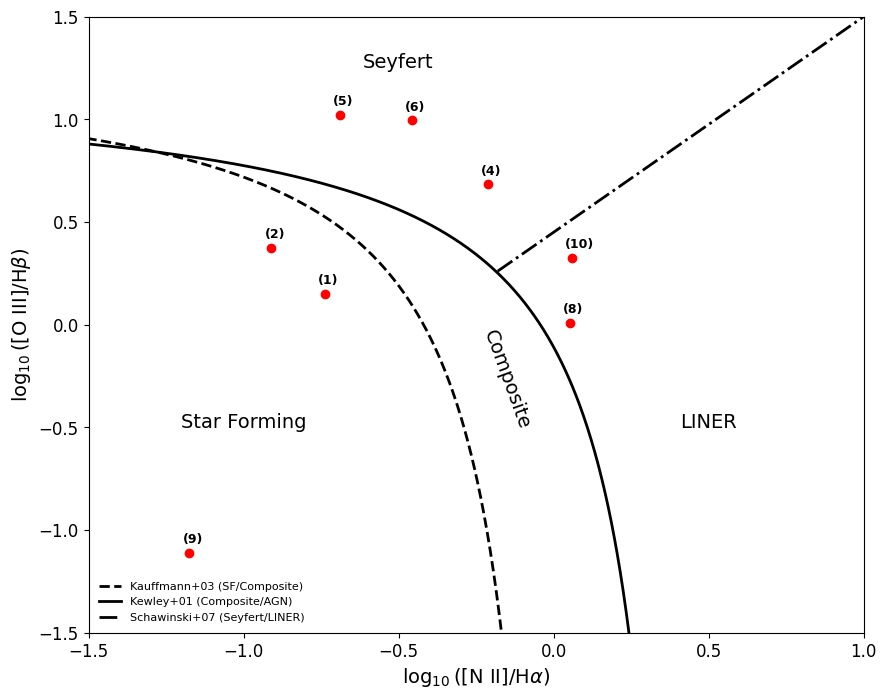

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

n2_ha = latent_overview_common_df["nii_to_halpha"].values
o3_hb = latent_overview_common_df["oiii_to_hbeta"].values
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)
# labels = latent_overview_common_df["name"].values
labels = [f"({i})" for i in range(1, 11)]

fig, ax = plot_bpt(
    fig,
    ax,
    log_n2_ha,
    log_o3_hb,
    labels,
    xytext=(-5, 5),
    x_lim=[-1.5, 1.0],
    y_lim=[-1.5, 1.5],
)

## IForest anomalies

In [21]:
iforest_overview_distinct_dict = {
    "oiii_mgrt_h_alpha": 1928785351883646976,
    "oiii_grt_h_alpha": 1969243798487721984,
    "oiii_sim_h_alpha_no_oii": 749873288389355520,
    "oiii_sim_h_alpha": 2390364730700097536,
    "h_alpha_grt_oiii": 694769887481980928,
}

latent_overview_common_df = get_overview_ratios_df(
    overview_dict=latent_overview_common_dict,
    meta_with_ratios_df=meta_with_ratios_df,
    cols_ratios=cols_ratios,
)

iforest_overview_df = get_overview_ratios_df(
    overview_dict=iforest_overview_distinct_dict,
    meta_with_ratios_df=meta_with_ratios_df,
    cols_ratios=cols_ratios,
)
iforest_overview_df.to_clipboard()
iforest_overview_df

,specobjid,name,class,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,1928785351883646976,oiii_mgrt_h_alpha,STARBURST,3.007305,0.036056,5.432463,5.061569,2.178015,0.130744,1.391704
1,1969243798487721984,oiii_grt_h_alpha,STARBURST,3.146264,0.036703,4.938868,NaN,2.128925,0.117187,1.454548
2,749873288389355520,oiii_sim_h_alpha_no_oii,STARBURST,3.116602,0.126734,2.353254,NaN,1.268776,0.196431,1.386627
3,2390364730700097536,oiii_sim_h_alpha,STARBURST,3.863180,0.121050,2.708597,2.442459,1.349780,0.210678,1.348419
4,694769887481980928,h_alpha_grt_oiii,STARBURST,3.600953,0.339277,0.981349,1.183687,0.461269,0.167921,1.269802


## BPT

['(1)', '(3)', '(5)', '(7)', '(9)']

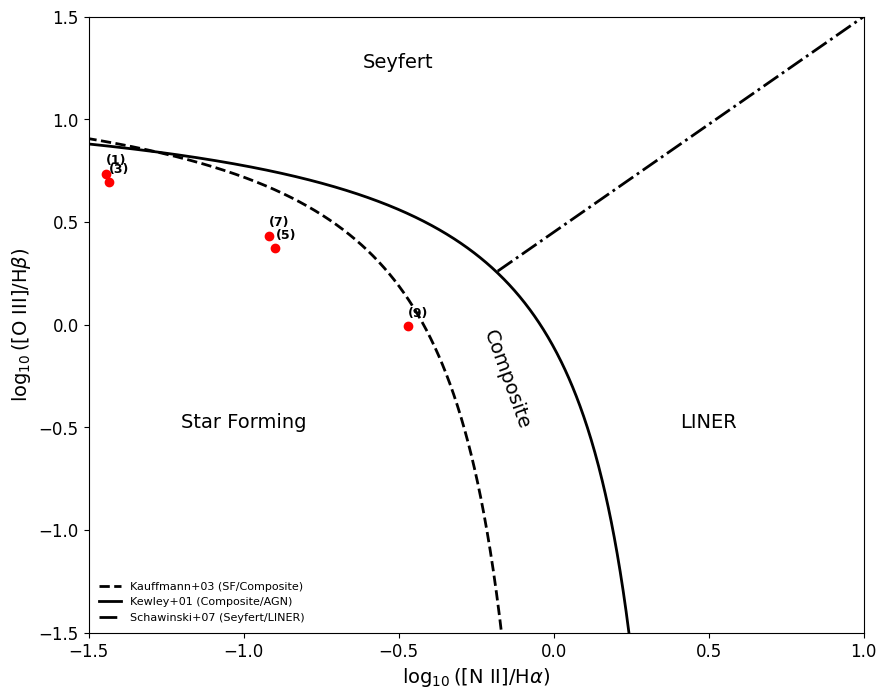

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

n2_ha = iforest_overview_df["nii_to_halpha"].values
o3_hb = iforest_overview_df["oiii_to_hbeta"].values
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)
labels = [f"({i})" for i in range(1, 10, 2)]

fig, ax = plot_bpt(log_n2_ha, log_o3_hb, labels, fig, ax)
labels

## LOF anomalies

In [22]:
lof_overview_distinct_dict = {
    "evolved": 395359395896125440,
    "evolved_H_alpha": 2501842015717713920,
    "evolved_sf": 873872364331362304,
    "weird_blue_excess": 3243851847563241472,
    "emission_line": 656537668875741184,
}
lof_overview_df = get_overview_ratios_df(
    overview_dict=lof_overview_distinct_dict,
    meta_with_ratios_df=meta_with_ratios_df,
    cols_ratios=cols_ratios,
)
lof_overview_df.to_clipboard()
lof_overview_df

,specobjid,name,class,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,395359395896125440,evolved,BROADLINE,3.866231,0.885910,2.068833,0.767019,0.368336,0.955329,0.984660
1,2501842015717713920,evolved_H_alpha,NaN,5.964753,0.567804,0.621456,2.266714,0.039212,0.369062,1.244971
2,873872364331362304,evolved_sf,BROADLINE,14.051773,0.678033,8.080090,2.686218,1.076165,0.285957,1.476534
3,3243851847563241472,weird_blue_excess,STARFORMING,2.719622,0.313977,1.342814,NaN,0.631118,0.347650,1.488162
4,656537668875741184,emission_line,STARBURST,4.001299,0.233724,1.225917,0.220530,0.719758,0.208023,1.127789


## BPT

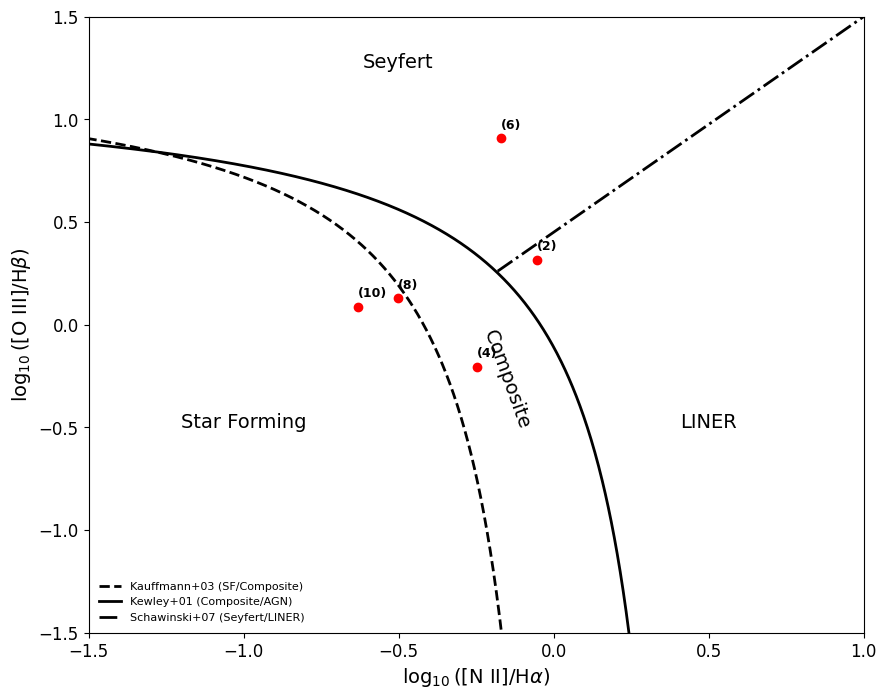

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))

n2_ha = lof_overview_df["nii_to_halpha"].values
o3_hb = lof_overview_df["oiii_to_hbeta"].values
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)
labels = [f"({i})" for i in range(2, 11, 2)]

fig, ax = plot_bpt(log_n2_ha, log_o3_hb, labels, fig, ax)